# Showcasing Cookbook Outputs with Jupyter GIS

## Overview

The analysis notebooks in this cookbook turn raw multibeam bathymetry into vector
**feature polygons**: the Topographic Position Index (TPI) method delineates highs and
lows from terrain curvature, and the openness method extracts exposed and enclosed
terrain from how much of the sky each cell can "see". This notebook brings those outputs
together and puts them on an interactive map with
[Jupyter GIS](https://github.com/geojupyter/jupytergis).

It has two purposes:

1. A **mini tutorial** on Jupyter GIS: how to open a map document, add a raster basemap,
   overlay vector features, and style them, all from Python inside JupyterLab.
2. A **showcase** of the processed output for the three survey areas used throughout this
   cookbook, with the TPI and openness feature polygons drawn on top of the bathymetry
   they were derived from.

We do the following:

1. Recall the three survey areas and (re)build their feature layers from the bathymetry.
2. Preview the layers as static maps so the rendered book shows the result.
3. Introduce the `GISDocument` API: raster layers, vector layers, and styling.
4. Assemble an interactive Jupyter GIS map for each survey area.

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| {doc}`Topographic-Position-Index-Method` | Helpful | Source of the TPI feature polygons |
| {doc}`openness_closeness_explainer` | Helpful | Source of the openness feature polygons |
| {doc}`Polygonization` | Helpful | How features are exported for GIS |
| [GeoPandas](https://geopandas.org/en/stable/getting_started/introduction.html) | Helpful | Vector features are held in a GeoDataFrame |
| Coordinate reference systems | Helpful | We move between projected and lon/lat CRSs |

- **Time to learn**: 30 minutes

```{note}
The interactive Jupyter GIS maps in this notebook only render inside a live JupyterLab
session, where the `jupytergis` extension is installed. The cells that build them are
therefore tagged `skip-execution`, so they are **not run when this book is built**. Each
one is paired with a static preview (drawn with Matplotlib) so the rendered page still
shows the result. Open the notebook in JupyterLab and run those cells to get the live,
pannable map.
```

---

## Imports

In [2]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import rasterio.features as rfeatures
from jupytergis import GISDocument
from matplotlib.colors import LightSource, Normalize
from matplotlib.lines import Line2D
from rasterio.plot import show as rio_show
from rasterio.warp import Resampling, calculate_default_transform, reproject
from scipy.ndimage import binary_closing, binary_opening, uniform_filter
from shapely.geometry import shape
from shapely.validation import make_valid

DATA = Path("../data")
FEATURES = DATA / "features"
TOPO = DATA / "topography"
FEATURES.mkdir(parents=True, exist_ok=True)
TOPO.mkdir(parents=True, exist_ok=True)

## The three survey areas

This cookbook works with three multibeam bathymetry grids, each in its own UTM
projection. They differ in size, depth range, and grid resolution, which makes them a
good test of a method's robustness.

| Key | Survey area | Grid resolution | Setting |
| --- | --- | --- | --- |
| `gifford` | Gifford Guyot | 50 m | A large seamount and its flanks |
| `os` | Sand-wave field | 2 m | A shallow, high-resolution bedform field |
| `pc` | Rocky reef | 3 m | A small, rugged reef block |

Each grid is stored as a GeoTIFF under `data/`. The cell below records the per-survey
settings we use when extracting features: the neighbourhood radius for each method and a
minimum polygon area that suppresses noise-sized features. These are tuned to each grid's
resolution and extent.

In [3]:
CASES = {
    "gifford": {
        "title": "Gifford Guyot",
        "tpi_radius": 25,
        "openness_radius": 20,
        "min_area_m2": 250_000,
    },
    "os": {
        "title": "Sand-wave field",
        "tpi_radius": 40,
        "openness_radius": 30,
        "min_area_m2": 2_500,
    },
    "pc": {
        "title": "Rocky reef",
        "tpi_radius": 40,
        "openness_radius": 30,
        "min_area_m2": 12_000,
    },
}


def load_bathy(case):
    """Read a survey GeoTIFF, masking the nodata sentinel to NaN."""
    with rio.open(DATA / f"{case}_bathy.tif") as src:
        z = src.read(1).astype("float64")
        z[z == src.nodata] = np.nan
        return z, src.transform, src.crs, src.res[0]

## Building the feature layers

The TPI and openness notebooks produce their polygons with the full GA-SaMMT workflow.
To keep this notebook self-contained, we rebuild comparable layers here with compact,
fast stand-ins of the same two ideas, exactly as the {doc}`Polygonization` notebook does
for its example data. Both reduce to: compute a per-cell terrain index, threshold it into
high and low classes, and vectorize the resulting masks into polygons.

In [4]:
def neighbourhood_mean(z, radius):
    """NaN-aware mean over a square neighbourhood, via a separable box filter."""
    w = 2 * radius + 1
    valid = np.isfinite(z).astype("float64")
    filled = np.where(np.isfinite(z), z, 0.0)
    num = uniform_filter(filled, size=w, mode="nearest")
    den = uniform_filter(valid, size=w, mode="nearest")
    out = np.full_like(z, np.nan)
    np.divide(num, den, out=out, where=den > 0)
    return out


def topographic_position_index(z, radius):
    """TPI: each cell minus the mean depth of its neighbourhood (a curvature proxy)."""
    tpi = z - neighbourhood_mean(z, radius)
    tpi[~np.isfinite(z)] = np.nan
    return tpi


def positive_openness(z, radius, cellsize):
    """Mean over eight azimuths of the zenith angle (degrees) to the highest horizon
    point within the search radius. Values above 90 are exposed/convex terrain (highs);
    below 90 are enclosed/concave terrain (lows)."""
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1)]
    total = np.zeros_like(z)
    count = np.zeros_like(z)
    for dr, dc in directions:
        step_dist = cellsize * np.hypot(dr, dc)
        max_beta = np.full_like(z, -np.inf)
        for s in range(1, radius + 1):
            shifted = np.full_like(z, np.nan)
            r0, r1 = max(0, -dr * s), z.shape[0] - max(0, dr * s)
            c0, c1 = max(0, -dc * s), z.shape[1] - max(0, dc * s)
            sr0, sr1 = max(0, dr * s), z.shape[0] - max(0, -dr * s)
            sc0, sc1 = max(0, dc * s), z.shape[1] - max(0, -dc * s)
            shifted[r0:r1, c0:c1] = z[sr0:sr1, sc0:sc1]
            beta = np.degrees(np.arctan((shifted - z) / (s * step_dist)))
            max_beta = np.fmax(max_beta, beta)
        zenith = 90.0 - max_beta
        good = np.isfinite(zenith)
        total[good] += zenith[good]
        count[good] += 1
    out = np.divide(total, count, out=np.full_like(z, np.nan), where=count > 0)
    out[~np.isfinite(z)] = np.nan
    return out

In [5]:
def _clean(mask):
    """Open then close a boolean mask with a 3x3 element, dropping one-cell speckle and
    the pinholes it leaves so polygon boundaries stay simple."""
    element = np.ones((3, 3), dtype=bool)
    return binary_closing(binary_opening(mask, element), element)


def _polygonize(mask, transform, feature_class, method):
    return [
        {"geometry": shape(g), "feature_class": feature_class, "method": method}
        for g, v in rfeatures.shapes(
            mask.astype(np.uint8), mask=mask, transform=transform
        )
        if v == 1
    ]


def extract_features(field, transform, crs, k, min_area_m2, method, simplify_tol):
    """Threshold a terrain index into high/low classes and vectorize them into a tidy,
    area-filtered, lightly simplified GeoDataFrame of feature polygons."""
    centred = field - np.nanmean(field)
    sd = np.nanstd(field)
    finite = np.isfinite(field)
    records = _polygonize(
        _clean(finite & (centred > k * sd)), transform, "high", method
    )
    records += _polygonize(
        _clean(finite & (centred < -k * sd)), transform, "low", method
    )

    gdf = gpd.GeoDataFrame(records, crs=crs)
    if len(gdf) == 0:
        return gdf
    gdf["geometry"] = gdf.geometry.apply(lambda g: g if g.is_valid else make_valid(g))
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()].copy()
    gdf["area_m2"] = gdf.area
    gdf = gdf[gdf["area_m2"] > min_area_m2].reset_index(drop=True)
    gdf["geometry"] = gdf.geometry.simplify(simplify_tol, preserve_topology=True)
    gdf = gdf[gdf.geometry.is_valid & ~gdf.geometry.is_empty].reset_index(drop=True)
    gdf["feature_id"] = gdf.index + 1
    gdf["area_m2"] = gdf["area_m2"].round(1)
    return gdf


def export_geojson(gdf, path):
    """Reproject to WGS84 and write a standards-compliant GeoJSON (see the Polygonization notebook)."""
    gdf.to_crs(epsg=4326).to_file(
        path, driver="GeoJSON", RFC7946="YES", COORDINATE_PRECISION=6
    )

Jupyter GIS draws its raster layers from a
[GeoTIFF](https://www.ogc.org/standards/geotiff). We turn each bathymetry grid into a
colour-shaded RGBA image, reproject it to Web Mercator (EPSG:3857, the projection web
maps use), and save it as a GeoTIFF so it can sit underneath the vector features as a
topography backdrop.

In [6]:
def write_topography_geotiff(z, transform, crs, path):
    """Render bathymetry as a hill-shaded, colour-relief RGBA image and save it as a
    Web Mercator GeoTIFF for use as a Jupyter GIS raster layer."""
    finite = np.isfinite(z)
    vmin, vmax = np.nanpercentile(z, [2, 98])
    rgb = mpl.colormaps["viridis"](Normalize(vmin, vmax)(np.where(finite, z, vmin)))[
        :, :, :3
    ]
    relief = LightSource(azdeg=315, altdeg=45).shade_rgb(
        rgb, np.where(finite, z, np.nanmin(z)), vert_exag=10, blend_mode="soft"
    )
    red, green, blue = (np.clip(relief, 0, 1) * 255).astype("uint8").transpose(2, 0, 1)
    alpha = np.where(finite, 255, 0).astype("uint8")

    dst_crs = "EPSG:3857"
    h, w = z.shape
    bounds = rio.transform.array_bounds(h, w, transform)
    dst_transform, dst_w, dst_h = calculate_default_transform(
        crs, dst_crs, w, h, *bounds
    )
    profile = {
        "driver": "COG",
        "dtype": "uint8",
        "count": 4,
        "crs": dst_crs,
        "transform": dst_transform,
        "width": dst_w,
        "height": dst_h,
        "compress": "deflate",
        "overview_resampling": "average",
    }
    with rio.open(path, "w", **profile) as dst:
        for i, band in enumerate([red, green, blue, alpha], start=1):
            out = np.zeros((dst_h, dst_w), dtype="uint8")
            reproject(
                band,
                out,
                src_transform=transform,
                src_crs=crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest if i == 4 else Resampling.bilinear,
            )
            dst.write(out, i)
        dst.colorinterp = [
            rio.enums.ColorInterp.red,
            rio.enums.ColorInterp.green,
            rio.enums.ColorInterp.blue,
            rio.enums.ColorInterp.alpha,
        ]

With the pieces in place, we process all three surveys: extract TPI and openness
features, write them to GeoJSON, and write the topography GeoTIFF. The output files land
under `data/features/` and `data/topography/`.

In [7]:
def build_layers(case):
    cfg = CASES[case]
    z, transform, crs, cellsize = load_bathy(case)
    tol = 2.0 * cellsize

    tpi = topographic_position_index(z, cfg["tpi_radius"])
    tpi_gdf = extract_features(tpi, transform, crs, 1.5, cfg["min_area_m2"], "TPI", tol)
    export_geojson(tpi_gdf, FEATURES / f"{case}_tpi_features.geojson")

    openness = positive_openness(z, cfg["openness_radius"], cellsize)
    openness_gdf = extract_features(
        openness, transform, crs, 1.0, cfg["min_area_m2"], "Openness", tol
    )
    export_geojson(openness_gdf, FEATURES / f"{case}_openness_features.geojson")

    write_topography_geotiff(z, transform, crs, TOPO / f"{case}_topo.tif")
    return len(tpi_gdf), len(openness_gdf)


for case in CASES:
    n_tpi, n_open = build_layers(case)
    print(
        f"{CASES[case]['title']:18s}: {n_tpi:3d} TPI polygons, {n_open:3d} openness polygons"
    )

Gifford Guyot     :  92 TPI polygons,  79 openness polygons
Sand-wave field   :  19 TPI polygons,  10 openness polygons
Rocky reef        :  32 TPI polygons,  14 openness polygons


## A static preview of the layers

Before opening the interactive map, we plot each survey the way Jupyter GIS will: the
topography GeoTIFF as a backdrop, with the TPI and openness feature outlines drawn on
top. Everything is shown in Web Mercator so the raster and vector layers line up.

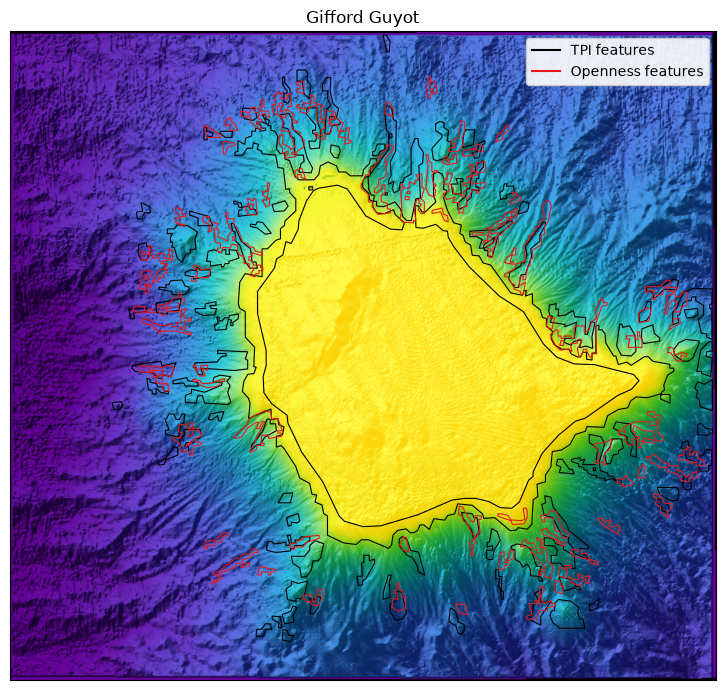

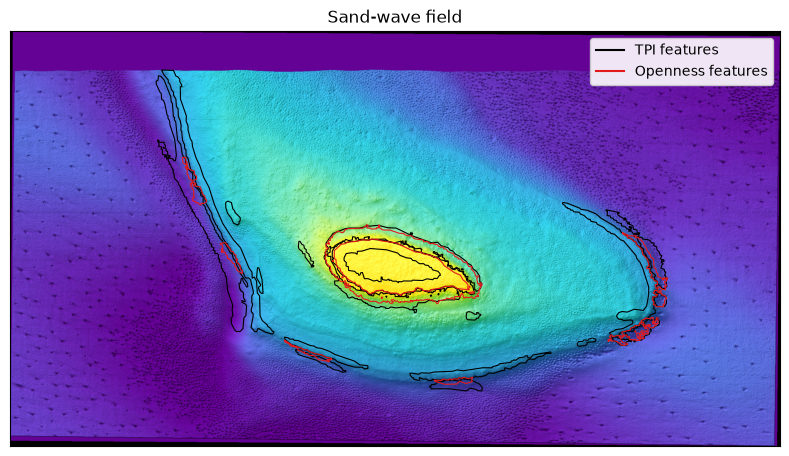

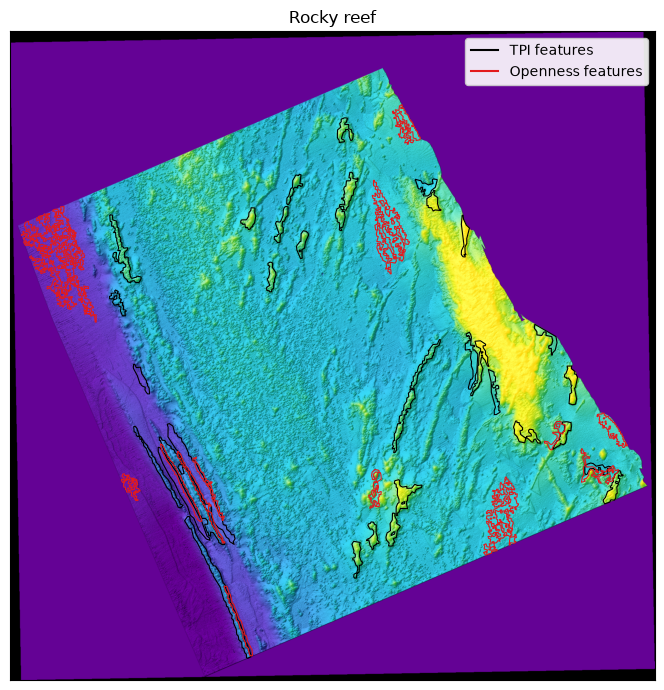

In [8]:
def preview(case, ax):
    cfg = CASES[case]
    with rio.open(TOPO / f"{case}_topo.tif") as topo:
        rio_show(topo.read(), transform=topo.transform, ax=ax)
    for fname, color in [
        (f"{case}_tpi_features.geojson", "black"),
        (f"{case}_openness_features.geojson", "#e31a1c"),
    ]:
        layer = gpd.read_file(FEATURES / fname).to_crs(epsg=3857)
        if len(layer):
            layer.boundary.plot(ax=ax, color=color, linewidth=0.8)
    ax.set_title(cfg["title"])
    ax.set_xticks([])
    ax.set_yticks([])


legend = [
    Line2D([0], [0], color="black", lw=1.5, label="TPI features"),
    Line2D([0], [0], color="#e31a1c", lw=1.5, label="Openness features"),
]

for case in CASES:
    fig, ax = plt.subplots(figsize=(8, 7))
    preview(case, ax)
    ax.legend(handles=legend, loc="upper right", framealpha=0.9)
    plt.tight_layout()
    plt.show()

These previews are static pictures. The rest of the notebook reproduces them as a
**live** Jupyter GIS map, where you can pan and zoom, toggle layers, click a polygon to
read its attributes, and restyle features from the layer panel.

## Introducing Jupyter GIS

[Jupyter GIS](https://github.com/geojupyter/jupytergis) is a GIS environment that runs
inside JupyterLab. From Python you create a **map document** and add **layers** to it; the
document renders as an interactive, collaborative map widget. The starting point is an
empty `GISDocument`, which opens a Web Mercator map with a default basemap.

In [23]:
doc = GISDocument()

We can open option this nextThis opens the map next to the notebook in a new JupyterLab tab.

In [24]:
doc.sidecar(title="Seabed Morphology", anchor="split-right")

Layers are added with `add_*` methods. The two we need are:

- `add_tiff_layer(url, ...)` for a raster, such as our topography GeoTIFF. We pass
  `normalize=False` because the image already holds final red/green/blue/alpha bytes.
- `add_geojson_layer(path, ...)` for vector features. It reads the file and embeds the
  geometry directly into the document.

The cell below builds a map for the Gifford survey: topography on the bottom, then the
TPI and openness features above it.

In [25]:
doc.add_tiff_layer(
    url="../data/topography/gifford_topo.tif",
    name="Bathymetry",
    normalize=False,
)
doc.add_geojson_layer(
    path="../data/features/gifford_tpi_features.geojson",
    name="TPI features",
    opacity=0.7,
)
doc.add_geojson_layer(
    path="../data/features/gifford_openness_features.geojson",
    name="Openness features",
    opacity=0.7,
)

'b935fe6b-1ae9-4f5b-a5ba-fdb9d25c99f1'

```{tip}
In the live widget, the **layer panel** on the left lists every layer. Use it to reorder
layers, toggle visibility, change opacity, and open the symbology editor to colour
features by an attribute such as `feature_class` or `area_m2`. Clicking a feature on the
map opens its attribute table.
```

### Styling features from Python

You can also set a layer's style when you add it, with a `color_expr`. It takes an
[OpenLayers flat style](https://openlayers.org/en/latest/apidoc/module-ol_style_flat.html)
expression evaluated per feature. Here we colour each polygon by its `feature_class`, so
highs and lows read differently at a glance.

In [22]:
high_low_style = {
    "fill-color": [
        "case",
        ["==", ["get", "feature_class"], "high"],
        "#d7301f",
        "#2c7fb8",
    ],
    "stroke-color": "#222222",
    "stroke-width": 0.6,
}


doc.add_tiff_layer(
    url="../data/topography/gifford_topo.tif", name="Bathymetry", normalize=False
)
doc.add_geojson_layer(
    path="../data/features/gifford_tpi_features.geojson",
    name="TPI features",
    opacity=0.7,
    color_expr=high_low_style,
)

'07279ad6-3ad1-4890-81cf-8eed14fe6378'

## Showcasing all three survey areas

The same three-layer recipe applies to every survey. We wrap it in a function so each
test case is one call. Run these cells in JupyterLab to explore each map; in the built
book they are skipped, and the static previews above stand in for them.

In [26]:
def showcase_map(case):
    """Assemble a Jupyter GIS map: topography backdrop plus TPI and openness features."""
    doc = GISDocument()
    doc.add_tiff_layer(
        url=f"../data/topography/{case}_topo.tif",
        name=f"{CASES[case]['title']} bathymetry",
        normalize=False,
    )
    doc.add_geojson_layer(
        path=f"../data/features/{case}_tpi_features.geojson",
        name="TPI features",
        opacity=0.7,
        color_expr=high_low_style,
    )
    doc.add_geojson_layer(
        path=f"../data/features/{case}_openness_features.geojson",
        name="Openness features",
        opacity=0.7,
        color_expr=high_low_style,
    )

    return doc

### Gifford Guyot

In [18]:
doc = showcase_map("gifford")
doc.sidecar(title="Gifford Guyot", anchor="split-right")

### Sand-wave field

In [19]:
doc = showcase_map("os")
doc.sidecar(title="Sand-wave field", anchor="split-right")

### Rocky reef

In [20]:
doc = showcase_map("pc")
doc.sidecar(title="Rocky reef", anchor="split-right")

## Summary

This notebook gathered the vector outputs of the cookbook's two feature-extraction
methods, TPI and openness, and showed them on an interactive map with Jupyter GIS. We
rebuilt the feature layers for all three survey areas, rendered the bathymetry as a
Web Mercator GeoTIFF backdrop, and learned the core `GISDocument` workflow: create a
document, add a raster layer with `add_tiff_layer`, overlay vector features with
`add_geojson_layer`, and style them by attribute with a `color_expr`. The same recipe
produced a showcase map for each test case, so the processed results of the whole
cookbook can be explored side by side, layer by layer.

### What's next?

From here you can bring in additional context layers, a basemap, or survey track lines,
classify the polygons into named geomorphic feature types, or export the styled map as a
`.jGIS` document to share with collaborators.

## Resources and References

- Jupyter GIS documentation: https://jupytergis.readthedocs.io/
- Jupyter GIS source: https://github.com/geojupyter/jupytergis
- OpenLayers flat style expressions: https://openlayers.org/en/latest/apidoc/module-ol_style_flat.html
- Cloud Optimized GeoTIFF: https://www.cogeo.org/
- GeoJSON standard, RFC 7946: https://datatracker.ietf.org/doc/html/rfc7946
- GeoPandas: https://geopandas.org/